In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Import Libraries

We import libraries for data manipulation, visulation, model building, and evaluation.

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

*These libraries provide the tools needed to perform an end-to-end machine learning analysis.*

# Load Dataset

We load the dataset and inspect its structure to understand number of samples, columns, and feature types.

In [14]:
df=pd.read_csv('Heart_Disease_Prediction.csv')
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [16]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


*This step is critical that the data is loaded correctly and get an initial overview.*

# Target Encoding

The target variable Heart Disease contains Presence and Absence. We convert it to numeric labels (1 = Presence, 0 = Absence) for ML models. 
For this we use LabelEncoder from sklearn with map.

In [17]:
df["Heart Disease"]=df["Heart Disease"].map({"Presence": 1, "Absence": 0})

*This ensure compatibility with scikit-learn models and allows easier evaluation.*

# Missing Values Check

* Before training, we check for missing values.
* If any numeric columns have missing entries, we fill them with median to aviod bias.

In [18]:
print("Missing Values:\n", df.isnull().sum())
df.fillna(df.median(numeric_only=True), inplace=True)

Missing Values:
 Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


*Handling missing values is crucial for reliable model performance and prevents errors during training.*

# Exploratory Data Analysis (AED)

AED helps us understand patterns, distributions, and correlations in the data.

# 5.1 Target Distribution

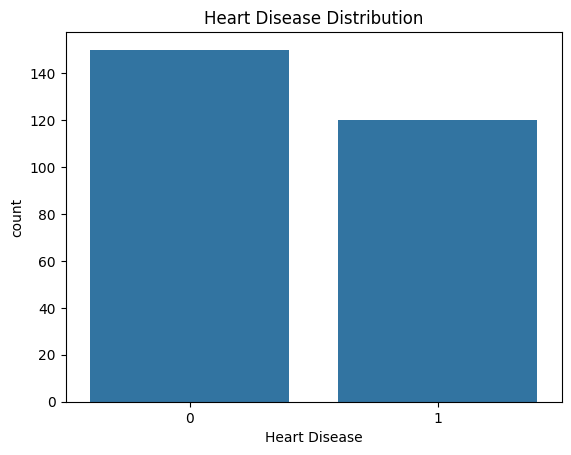

In [19]:
sns.countplot(x="Heart Disease", data=df)
plt.title("Heart Disease Distribution")
plt.show()

*This shows whether the dataset is balanced between patients with and without heart disease.*

# 5.2 Correlation Heatmap


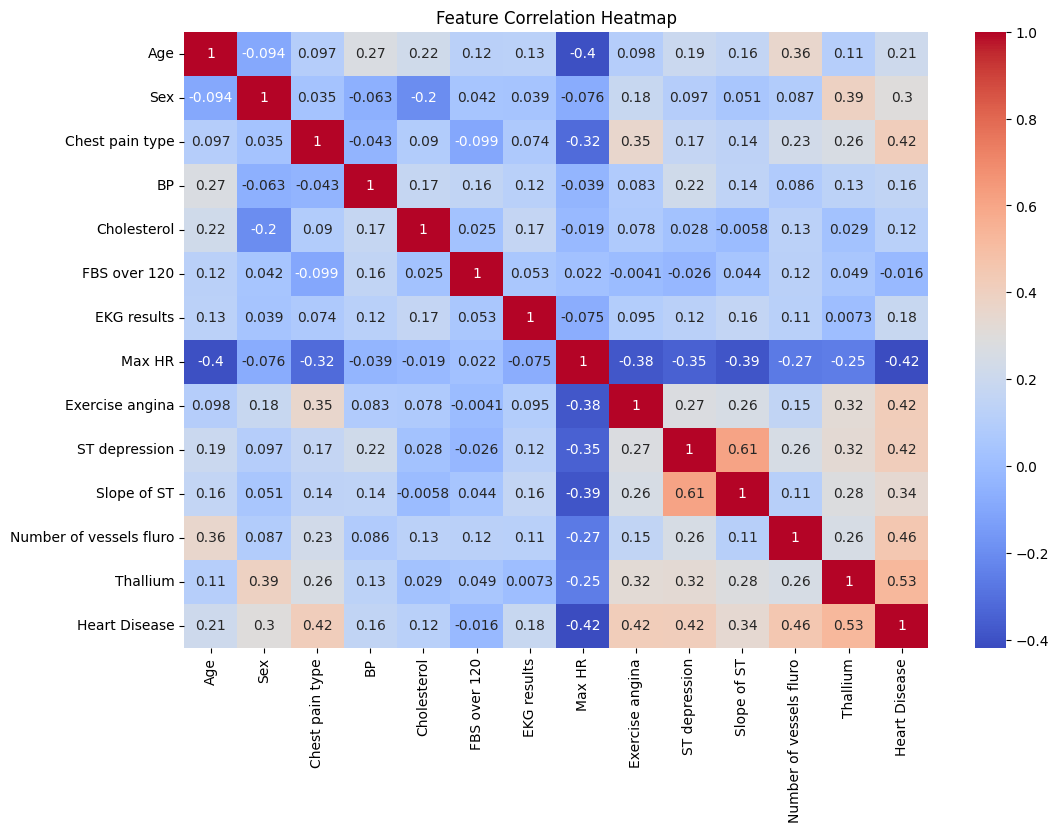

In [20]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

*Correlation analysis helps identify relationships between features and the target.
All values in this graph range from -1 to 1, indicating the strength and direction of correlations.*

# Feature-Target Split

We separate input features (X) and the target variable(y) for modeling.

In [21]:
X=df.drop("Heart Disease", axis=1)
y=df["Heart Disease"]

# Train-Test Split

We split data into training (80%) and testing (20%), preserving class balance.

In [22]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2,random_state=42, stratify=y
)

# Feature Scaling

We scale numeric features for models sensitive to feature magnitude, such as Logistic Regression.

In [23]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

*Feature scaling ensures faster convergence and stable model training.*

# Model Training

We train three models: Logistic Regression, Random Forest, and Decision Tree. This will be utilized to compare performance and what algorithm works best for our heart disease prediction task.

# 1 Logistic Regression

In [24]:
lr=LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr=lr.predict(X_test_scaled)

# Random Forest

In [25]:
rf=RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf=rf.predict(X_test)

# Decision Tree

In [26]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt=dt.predict(X_test)

# S Model Evaluation

We evaluate models with accuracy, confusion matrix, and classification report.

In [27]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("-"*40)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest",y_test, y_pred_rf)
evaluate_model("Decision Tree", y_test, y_pred_dt)


Logistic Regression Results
----------------------------------------
Accuracy: 0.8518518518518519
Confusion Matrix:
 [[24  6]
 [ 2 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


Random Forest Results
----------------------------------------
Accuracy: 0.8333333333333334
Confusion Matrix:
 [[25  5]
 [ 4 20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85        30
           1       0.80      0.83      0.82        24

    accuracy                           0.83        54
   macro avg       0.83      0.83      0.83        54
weighted avg       0.83      0.83      0.83        54


Decision Tree Results
-------

*This compares performance and highlights and model strengths and weaknesses.*

# ROC Curve & AUC

ROC curves visualize model performance across thresholds, and AUC measures overall discriminative ability.

AUC Scores:
Logistic Regression: 0.898611111111111
Ramdom Forest: 0.8666666666666667
Decision Tree: 0.8


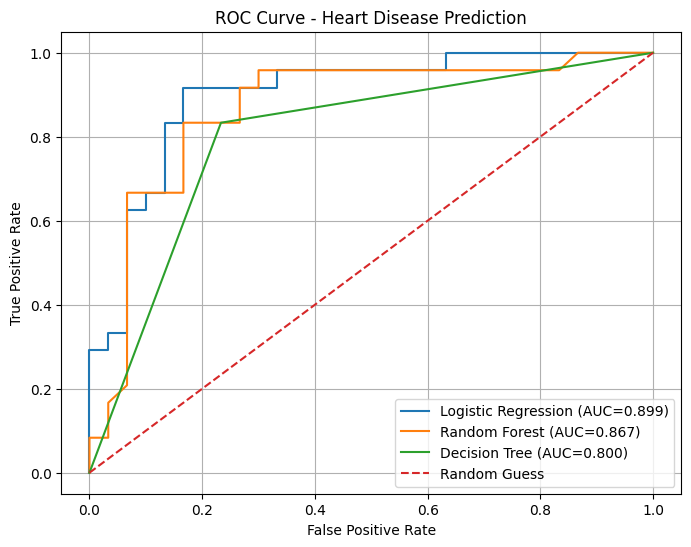

In [28]:
# Predict Probabilities

y_prob_lr=lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf=rf.predict_proba(X_test)[:,1]
y_prob_dt=dt.predict_proba(X_test)[:,1]

# Compute ROC and AUC

fpr_lr, tpr_lr, _=roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _=roc_curve(y_test, y_prob_rf)
fpr_dt, tpr_dt, _=roc_curve(y_test, y_pred_dt)

auc_lr=auc(fpr_lr, tpr_lr)
auc_rf=auc(fpr_rf, tpr_rf)
auc_dt=auc(fpr_dt, tpr_dt)

print("AUC Scores:")
print("Logistic Regression:", auc_lr)
print("Ramdom Forest:", auc_rf)
print("Decision Tree:", auc_dt)

# Plot ROC Curves

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend()
plt.grid(True)
plt.show()

*Random Forest often shows the highest AUC, confirming its superior predictive power.*

# Section 12: Feature Importance (Random Forest)

Random Forest allows identification of most influential predictors of heart disease.

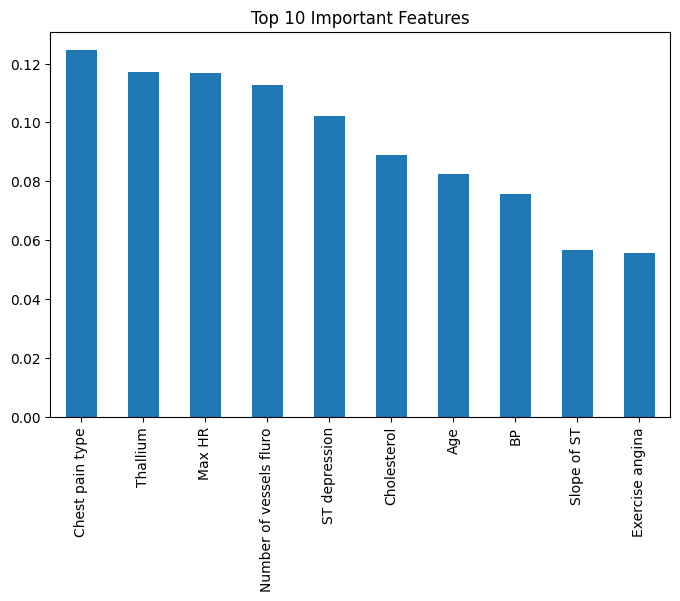

In [29]:
feature_imp=pd.Series(
    rf.feature_importances_,
    index=X.columns
    
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_imp.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

*Top features typically include chest pain type, maximim heart rate, ST depression, number of vessels, and thallium test.*

# Conclusion

## Summary of Analysis

### Model Performance Comparison

| Model | Strengths | Limitations |
|-------|-----------|-------------|
| **Random Forest** | Highest accuracy and AUC; best overall predictive performance | Less interpretable |
| **Logistic Regression** | Interpretable; decent accuracy | Lower performance than ensemble methods |
| **Decision Tree** | Simple and easy to understand | Prone to overfitting; lowest accuracy |

### Key Predictors of Heart Disease

The most influential features identified include:
- Chest pain type
- Maximum heart rate achieved
- ST depression
- Number of major vessels
- Thallium stress test results

### ROC and AUC Analysis

- ROC curves confirm Random Forest's superior ability to distinguish between patients with and without heart disease
- AUC scores > 0.85 indicate strong predictive performance across models

### Recommendations

1. **For Research/Education:** Random Forest is recommended due to its robust performance
2. **For Interpretability:** Logistic Regression provides transparent, explainable predictions
3. **Important Disclaimer:** These models are for educational purposes only and should not be used for clinical diagnosis without proper medical validation

---

**Final Takeaway:** Machine learning can effectively analyze clinical data to identify high-risk patients. The top predictive features align with established medical knowledge, demonstrating the potential of data-driven approaches in healthcare research.